# Service Tickets Analysis - 

In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

import pandas as pd
import numpy as np
import os

from dotenv import load_dotenv

load_dotenv()

True

In [2]:
# load data
dataset = os.getenv("DATASET_PATH", "")
df = pd.read_csv(dataset)
df = df.head(10)

In [3]:
# vectorize
vectorizer = TfidfVectorizer(max_features=1000)

X = vectorizer.fit_transform(df["Document"])

df.shape[0], X.shape[1]

(10, 248)

In [4]:
# cluster
kmeans = KMeans(n_clusters=5, random_state=42, n_init='auto')
df['cluster'] = kmeans.fit_predict(X)

# metrics
sil = silhouette_score(X, df['cluster'])

round(sil, 4)

0.0011

In [5]:
# build EKG

G = nx.Graph()
for idx, row in df.iterrows():
    G.add_edge(f"i{idx}", f"c{row['cluster']}")
    G.add_edge(f"i{idx}", row['Topic_group'])

print(f"EKG: {G.number_of_nodes()} nodes | {G.number_of_edges()} edges")

EKG: 19 nodes | 20 edges


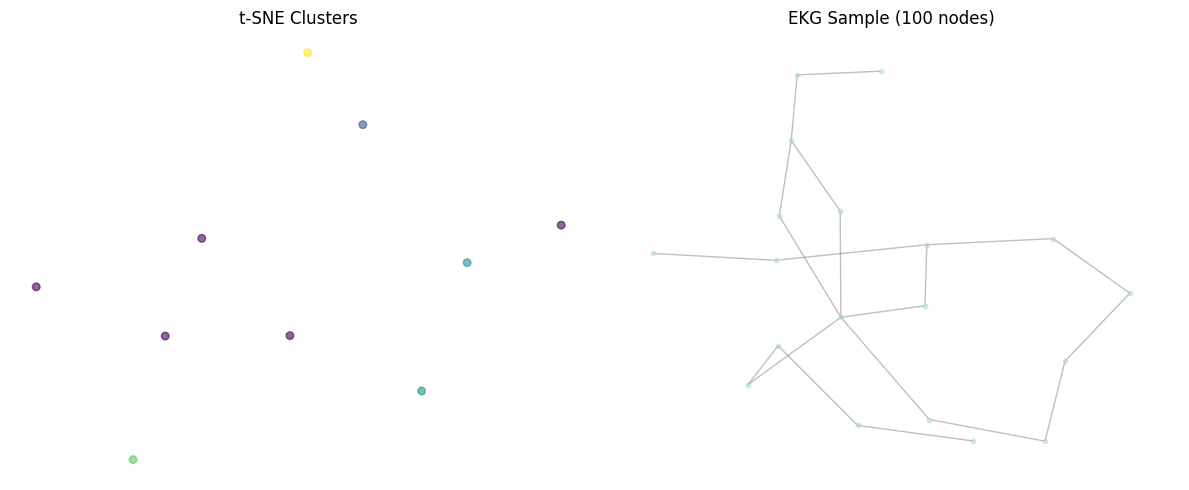

In [7]:
# Visualize
plt.figure(figsize=(12, 5))

# t-SNE
from sklearn.manifold import TSNE
from sklearn.decomposition import TruncatedSVD

X_red = TruncatedSVD(n_components=30, random_state=42).fit_transform(X)
X_2d = TSNE(n_components=2, random_state=42, perplexity=5).fit_transform(X_red)

plt.subplot(121)
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=df["cluster"], cmap="viridis", alpha=0.6, s=30)
plt.title("t-SNE Clusters")
plt.axis("off")

# Network sample
plt.subplot(122)
sample = list(G.nodes())[:100]
subG = G.subgraph(sample)
pos = nx.spring_layout(subG, k=0.3, iterations=20, seed=42)
nx.draw(
    subG,
    pos,
    node_size=10,
    node_color="lightblue",
    edge_color="gray",
    alpha=0.5,
    with_labels=False,
)
plt.title("EKG Sample (100 nodes)")
plt.axis("off")

plt.tight_layout()
plt.show()